### SECTION 1 — Introduction

In the previous analysis, we developed and validated a first-order thermal model.

The key question now is:

Can this model be used to guide real energy decisions?

### SECTION 2 — Load & Setup (Code)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load sample data
DATA_PATH = "../data/sample/PreliminaryAnalysis.csv"
df_raw = pd.read_csv(DATA_PATH)

In [3]:
# Import dataset from csv 
min_date = pd.to_datetime('2026-02-25 00:00:00')
max_date = pd.to_datetime('2026-03-02 23:00:00')
df_raw['time'] = pd.to_datetime(df_raw['time'])
df_filtered = df_raw.loc[(df_raw['time'] >= min_date) & (df_raw['time'] <= max_date)]
df_filtered = df_filtered.set_index("time")

In [4]:
def simulate_first_order_with_dynamic_solar(
    T0, 
    Tout_local_series,
    Tout_north_series,
    Tout_south_series,
    k,
    alpha,
    dt=1.0
):
    """
    First-order thermal model with dynamic solar proxy:
    
    T_{t+1} = T_t + [-k*(T_t - T_out_ref) + alpha * max(T_out_south - T_out_north, 0)] * dt
    
    Parameters
    ----------
    T0 : float
        Initial indoor temperature
    Tout_local_series : pd.Series
        Outdoor reference temperature for the room (e.g. north outdoor for north room)
    Tout_north_series : pd.Series
        North outdoor temperature
    Tout_south_series : pd.Series
        South outdoor temperature
    k : float
        Heat loss coefficient [1/h]
    alpha : float
        Dynamic solar gain scaling factor
    dt : float
        Time step in hours
    """
    idx =Tout_local_series.index
    Tsim = np.zeros(len(idx), dtype=float)
    Tsim[0] = T0

    solar_proxy = np.maximum((Tout_south_series - Tout_north_series).to_numpy(dtype=float), 0.0)

    for i in range(1, len(idx)):
        T_prev = Tsim[i - 1]
        T_out_ref = float(Tout_local_series.iloc[i - 1])
        solar_term = alpha * solar_proxy[i - 1]

        Tsim[i] = T_prev + (-k * (T_prev - T_out_ref) + solar_term) * dt
    return pd.Series(Tsim, index=idx, name="Tsim_v3")

### SECTION 3 — Baseline Simulation

In [11]:
# Parameters definition
column_in = "temp_salon_c"
column_out = "temp_out_1_b_c"
k_opt = 0.007526 # as found in parameters_indentification
alpha_opt = 0.036258
dt = 1.0 # hours

column_in = "temp_salon_c"
column_out_north = "temp_out_1_b_c"
column_out_south = "temp_out_2_n_c"

df_sim = df_filtered.loc[min_date:max_date, [
    column_in,
    column_out_north,
    column_out_south
]].dropna().copy()

T0 = df_sim[column_in].iloc[0]

df_sim["Tsim_baseline"] = simulate_first_order_with_dynamic_solar(
    T0=T0,
    Tout_local_series=df_sim[column_out_north],
    Tout_north_series=df_sim[column_out_north],
    Tout_south_series=df_sim[column_out_south],
    k=k_opt,
    alpha=alpha_opt,  
    dt=dt
)

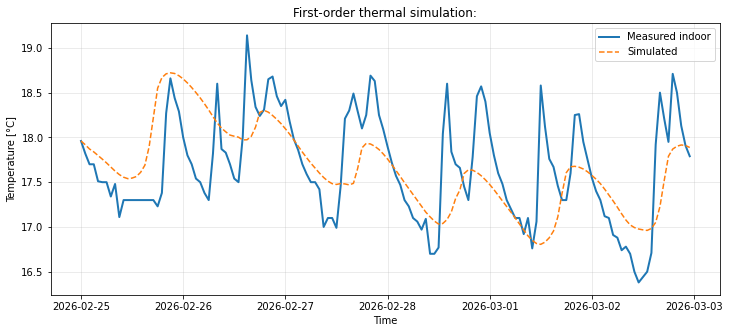

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(df_sim.index, df_sim[column_in], label="Measured indoor", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_baseline"], label="Simulated", linestyle="--")

plt.title("First-order thermal simulation")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### SECTION 4 — Define Scenarios 

We now explore how changes in thermal properties affect performance.

We simulate a hypothetical improvement in insulation.

In [13]:
k_baseline = k_opt
k_improved = 0.8 * k_opt  # 20% improvement

In [14]:
df_sim["Tsim_improved"] = simulate_first_order_with_dynamic_solar(
    T0=T0,
    Tout_local_series=df_sim[column_out_north],
    Tout_north_series=df_sim[column_out_north],
    Tout_south_series=df_sim[column_out_south],
    k=k_improved,
    alpha=alpha_opt,  
    dt=dt
)

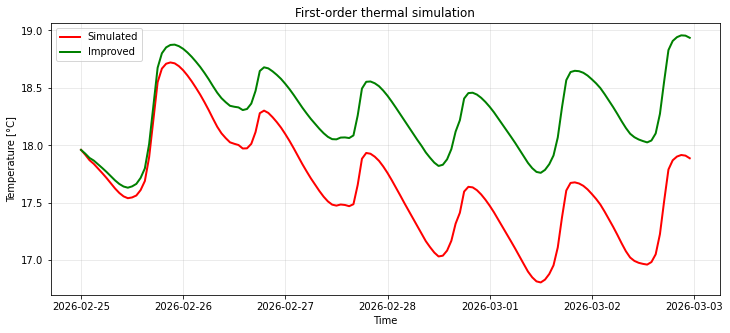

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(df_sim.index, df_sim["Tsim_baseline"], label="Simulated", color="red", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_improved"], label="Improved", color="green", linewidth=2)

plt.title("First-order thermal simulation")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### SECTION 6 — Quantification

Let's consider the following energy proxy - as we did in notebook _02_ua_estimation_ (Heat Loss Indicator):

In [21]:
Tout = df_sim[column_out_north]
Tin_baseline = df_sim["Tsim_baseline"]
Tin_improved = df_sim["Tsim_improved"]

heat_loss_baseline = k_baseline * (Tin_baseline - Tout)
heat_loss_improved = k_improved * (Tin_improved - Tout)

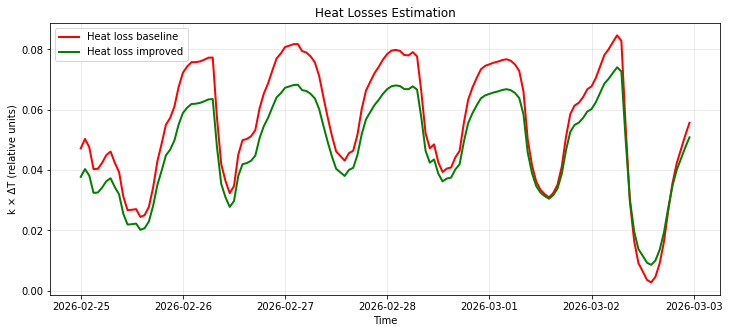

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(df_sim.index, heat_loss_baseline, label="Heat loss baseline", linewidth=2, color="red")
plt.plot(df_sim.index, heat_loss_improved, label="Heat loss improved", linewidth=2, color="green")

plt.title("Heat Losses Estimation")
plt.xlabel("Time")
plt.ylabel("k × ΔT (relative units)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Cumulative savings based on defined energy proxy: 1.0538472390002624


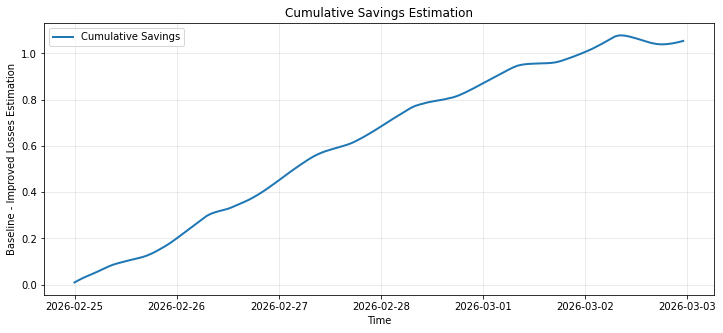

In [25]:
# cumulative difference
cumulative_savings = (heat_loss_baseline - heat_loss_improved).cumsum()
print(f"Cumulative savings based on defined energy proxy: {cumulative_savings[-1]}")

plt.figure(figsize=(12, 5))
plt.plot(df_sim.index, cumulative_savings, label="Cumulative Savings", linewidth=2)

plt.title("Cumulative Savings Estimation")
plt.xlabel("Time")
plt.ylabel("Baseline - Improved Losses Estimation")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Section 7 - Key Results
A 20% reduction in the heat loss coefficient results in:

- Lower temperature decay rates
- Improved thermal stability
- Reduced overall heat loss

### Section 8 - Room Comparison

In [30]:
from scipy.optimize import minimize

def objective(params):
    k, alpha = params
    
    T_sim = simulate_first_order_with_dynamic_solar(
        T0, 
        df_sim[column_out_south],
        df_sim[column_out_north],
        df_sim[column_out_south],
        k,
        alpha,
        dt=1.0
    )
    
    return np.mean(np.abs(df_sim[column_in] - T_sim))

bounds = [
    (0.001, 0.05),   # k
    (0.0, 0.2),      # alpha
]

result = minimize(objective, x0=(0.01, 0.05), bounds=bounds)

k_opt, alpha_opt = result.x

print(f"k_opt = {k_opt:.5f}")
print(f"alpha_opt = {alpha_opt:.5f}")


k_opt = 0.00763
alpha_opt = 0.02940
